1. Problem Statement
2. Import Libraries
3. Data Loading
4. Data Understanding
5. Data Cleaning
6. EDA
7. Feature Engineering
8. Prepare Data for Modeling
9. Modeling
10. Evaluation
11. Conclusion
   

# Telco Customer Churn

## 1.Problem Statement
"Predict behavior to retain customers. Analyze all relevant customer data and develop focused customer retention programs." 


## 2. Import Libraries

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


## 3. Data Loading

In [46]:
df = pd.read_csv("../data/Telco-Customer-Churn.csv")
df.head() 

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 4. Data Understanding

In [47]:

# first look
print(df.head())

# shape of data
print("Shape:", df.shape)

# basic info
print(df.info())

# column names
print("Columns:")
print(df.columns)

# summary statistics
print(df.describe())

print(df['Churn'].value_counts())


   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [48]:
#Check Missing Values (VERY IMPORTANT)
df.isnull().sum().sort_values(ascending=False)

customerID          0
DeviceProtection    0
TotalCharges        0
MonthlyCharges      0
PaymentMethod       0
PaperlessBilling    0
Contract            0
StreamingMovies     0
StreamingTV         0
TechSupport         0
OnlineBackup        0
gender              0
OnlineSecurity      0
InternetService     0
MultipleLines       0
PhoneService        0
tenure              0
Dependents          0
Partner             0
SeniorCitizen       0
Churn               0
dtype: int64

## 5. Data Cleaning

In [49]:
# Step1 :   null values check and fix it
# Step2 : Data Types (Important finding)
# Step 3: Fix Data Issues (First Cleaning Step)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

#This converts: numbers → correct blanks → NaN
df["TotalCharges"].isnull().sum()
print(df["TotalCharges"].isnull().sum())
# step 4 : fix the missing values 


df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())


cat_cols = df.select_dtypes(include=["object"]).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

num_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

#Step 5: Drop useless column
df.drop("customerID", axis=1, inplace=True)


#Step 6: Target Encoding
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Check imbalance
print(df["Churn"].value_counts())



11
Churn
0    5174
1    1869
Name: count, dtype: int64


## 6.Exploratory Data Analysis

In [50]:

# Business insights for Contract
print(pd.crosstab(df["Contract"], df["Churn"], normalize="index"))

# Business insights for InternetService

print(pd.crosstab(df["InternetService"], df["Churn"], normalize="index"))


# Business insights for InternetService

print(pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index"))

print(df.groupby("Churn")["tenure"].mean())
print(df.groupby("Churn")["MonthlyCharges"].mean())

Churn                  0         1
Contract                          
Month-to-month  0.572903  0.427097
One year        0.887305  0.112695
Two year        0.971681  0.028319
Churn                   0         1
InternetService                    
DSL              0.810409  0.189591
Fiber optic      0.581072  0.418928
No               0.925950  0.074050
Churn                             0         1
PaymentMethod                                
Bank transfer (automatic)  0.832902  0.167098
Credit card (automatic)    0.847569  0.152431
Electronic check           0.547146  0.452854
Mailed check               0.808933  0.191067
Churn
0    37.569965
1    17.979133
Name: tenure, dtype: float64
Churn
0    61.265124
1    74.441332
Name: MonthlyCharges, dtype: float64


# Analysis and business meaning 
# Contract vs Churn

🧠 Interpretation
Month-to-month → 43% churn 😱
One year → 11% churn
Two year → 3% churn
💡 Insight

🔥 Short-term customers are risky
🔥 Long-term contracts are stable

🧠 Business meaning
People not committed → leave easily
Long contracts → higher loyalty

# InternetService vs Churn

🧠 Interpretation
Fiber optic → 42% churn 😱 (very high)
DSL → ~19% churn
No internet → very low churn
⚠️ Important thinking

At first glance:

“Fiber is better tech → why more churn?”

💡 Real insight

This is not technical — it's behavioral/business:

👉 Possible reasons:

Fiber is expensive → customers leave
Higher expectations → dissatisfaction
Competitive market → easy switching

# PaymentMethod vs Churn

🧠 Interpretation
Electronic check → 45% churn 😱 (highest)
Automatic payments → lowest churn
💡 Insight

Customers who manually pay are more likely to churn

🧠 Business reasoning
Auto-pay → committed customers
Manual payment → less engagement
friction → churn

🔥 Combine All Insights (THIS IS THE GOLD)

Now think like a product/strategy person:

🚨 High-risk customers

A customer with:

Month-to-month contract
Fiber optic
Electronic check

👉 = very high churn probability

🧠 Low-risk customers

A customer with:

2-year contract
Auto payment
No/DSL

👉 = very stable

🎯 THIS is why we do EDA

Not just to plot charts.

But to answer:

“Which customers are likely to leave and why?”

Customers who stay → pay ~61/month
Customers who churn → pay ~74/month

Key Insights
Customers on month-to-month contracts have the highest churn (~43%)
Fiber optic users show significantly higher churn (~42%)
Customers using electronic check payments churn the most (~45%)
Customers with low tenure (~18 months) are more likely to churn
Higher monthly charges (~74) are associated with increased churn

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

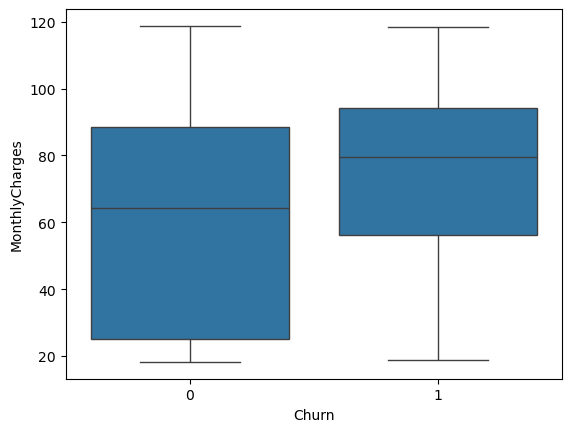

In [51]:
import seaborn as sns
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)


## 7.Feature Engineering

In [52]:
#Explanation : Positive coefficients increase churn probability, while negative coefficients reduce it.
#For example, Fiber optic and Electronic check increase churn risk, while long-term contracts reduce it.
    
df["AvgMonthlySpend"] = df["TotalCharges"] / (df["tenure"] + 1)
df["IsLongTerm"] = (df["tenure"] > 24).astype(int)



## 8.Prepare Data for Modeling :  
## Data Preparation

In [53]:
# Prepare data
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Encode categorical features
X = pd.get_dummies(X, drop_first=True)




In [54]:

# Train/test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 9. Modeling

## Improve the model with pipeline and Threshold tuning


In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(class_weight="balanced", max_iter=5000))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

scores = cross_val_score(pipeline, X, y, cv=5, scoring="recall")

print("Recall scores:", scores)
print("Mean Recall:", scores.mean())
print(classification_report(y_test, y_pred))

#confusion_matrix
#TP → correctly predicted churn
#FN → missed churn (important!)
#False Negatives (missed churners) are critical because they represent customers we fail to retain.
print(confusion_matrix(y_test, y_pred))


y_prob = pipeline.predict_proba(X_test)[:, 1]
y_pred = (y_prob > 0.3).astype(int)

#ROC-AUC measures how well the model separates churn vs non-churn customers.
print(roc_auc_score(y_test, y_prob))

import pandas as pd

pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Probability": y_prob
}).head(10)


coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": pipeline.named_steps["model"].coef_[0]
}).sort_values(by="Coefficient", ascending=False)

print(coef_df.head(10))

Recall scores: [0.83957219 0.81550802 0.79144385 0.78552279 0.76737968]
Mean Recall: 0.7998853063038522
              precision    recall  f1-score   support

           0       0.92      0.74      0.82      1036
           1       0.54      0.83      0.65       373

    accuracy                           0.76      1409
   macro avg       0.73      0.78      0.74      1409
weighted avg       0.82      0.76      0.78      1409

[[769 267]
 [ 65 308]]
0.8618332522488018
                           Feature  Coefficient
12     InternetService_Fiber optic     0.909528
3                     TotalCharges     0.597374
25             StreamingMovies_Yes     0.378139
23                 StreamingTV_Yes     0.325609
11               MultipleLines_Yes     0.251570
28            PaperlessBilling_Yes     0.156127
30  PaymentMethod_Electronic check     0.143461
19            DeviceProtection_Yes     0.086568
5                       IsLongTerm     0.062170
0                    SeniorCitizen     0.059820

# Analysis 
Scores are close to each other:

not jumping like 0.50 → 0.90 (bad)
instead: ~0.76 → ~0.83 (good)

Model shows stable performance across folds, indicating good generalization and low risk of overfitting.



ROC-AUC measures how well the model separates churn vs non-churn customers.

# Diff between Precision & Recall
Precision → quality of predictions  
Recall → coverage of reality
Example : 

100 customers actually churn
Your model predicts 120 customers will churn

Out of those 120 predicted:

80 actually churn
40 do NOT churn
🔹 Precision
Precision = TP / (TP + FP)
= 80 / 120 = 0.67

👉 “Of all predicted churners, 67% were correct”

🔹 Recall
Recall = TP / (TP + FN)
= 80 / 100 = 0.80

👉 “Out of all real churners, I caught 80%”

# Hyperparameter tuning

In [56]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {"C": [0.01, 0.1, 1, 10]}

grid = GridSearchCV(
    LogisticRegression(max_iter=5000, class_weight="balanced"),
    param_grid,
    scoring="recall",
    cv=5
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best recall:", grid.best_score_)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please a

Best params: {'C': 10}
Best recall: 0.7987915273132664


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Analysis of GridSearchCV
Hyperparameters (we control)
Logistic Regression → C
Lasso → alpha
Random Forest → n_estimators, max_depth

What is Hyperparameters ? 

Ingredients = data
Recipe = model
Spice level = hyperparameters

Cross-validation = evaluate model
GridSearchCV = optimize model using cross-validation

It tries:

C = 0.01 → evaluate
C = 0.1 → evaluate
C = 1 → evaluate
C = 10 → evaluate

using cross-validation
picks best based on recall




# Analysis of GridSearchCV 

Lowering threshold increases recall, allowing the model to capture more churners at the cost of precision.

# RandomForestClassifier

In [57]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_rf))
from sklearn.model_selection import cross_val_score

scores_rf = cross_val_score(rf, X, y, cv=5, scoring="recall")

print("RF Recall scores:", scores_rf)
print("RF Mean Recall:", scores_rf.mean())

              precision    recall  f1-score   support

           0       0.83      0.92      0.87      1036
           1       0.66      0.46      0.54       373

    accuracy                           0.80      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.80      0.78      1409

RF Recall scores: [0.47326203 0.49197861 0.44385027 0.47989276 0.49197861]
RF Mean Recall: 0.47619245602213595


# Final Model outcome 
Final Model:
Logistic Regression (C=10, class_weight="balanced", max_iter=5000))
Recall ≈ 0.80
ROC-AUC ≈ 0.86
Threshold = 0.3

Business Value:
Model helps identify high-risk customers early, enabling targeted retention strategies.

In [58]:
final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(C=10, class_weight="balanced", max_iter=5000))
])

final_model.fit(X_train, y_train)



,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,10


In [59]:
import pickle

# Save model
with open("../models/churn_model.pkl", "wb") as f:
    pickle.dump(final_model, f)

# Save columns (VERY IMPORTANT)
with open("../models/model_columns.pkl", "wb") as f:
    pickle.dump(X.columns.tolist(), f)


I demostrated below 

✅ ML fundamentals
✅ Business understanding
✅ Model evaluation thinking
✅ Trade-offs (precision vs recall)
✅ Deployment awareness
✅ Feature interpretation

This project includes 
Structure
   flow (Problem → EDA → Modeling → Conclusion)
EDA
Modeling
Pipeline 
Class balancing 
Cross-validation 
Metrics
    Recall-focused
    ROC-AUC added
Interpretation
    Coefficients
    Feature importance visible
Comparison
Random Forest tested → rejected with reasoning
Final Model
    Logistic Regression (C=10)
    Recall ≈ 0.80
    ROC-AUC ≈ 0.86
    Threshold = 0.3
## Conclusion

In this project, I built an end-to-end machine learning solution to predict customer churn using the Telco dataset.

Through exploratory data analysis, I identified key behavioral patterns driving churn, such as short-term contracts, higher monthly charges, and manual payment methods. These insights helped guide feature engineering and model design.

A Logistic Regression model with class balancing and threshold tuning was selected as the final model, achieving:
- Recall ≈ 0.80
- ROC-AUC ≈ 0.86

This model prioritizes identifying potential churners, enabling proactive customer retention strategies.

Overall, this project demonstrates not only model building, but the ability to translate data into actionable business insights and deploy a production-ready ML pipeline.